In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib, ast, os, warnings
warnings.filterwarnings('ignore')

from collections import Counter
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.multioutput import ClassifierChain
from sklearn.model_selection import train_test_split
from sklearn.metrics import hamming_loss, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from xgboost import XGBClassifier
from sentence_transformers import SentenceTransformer

print("All libraries imported ✅")

All libraries imported ✅


In [2]:
print("Loading datasets...")
new_df         = pd.read_csv('../datasets/stage3/medicine_dataset.csv')
drugs_df       = pd.read_csv('../datasets/stage2/drugs_side_effects_drugs_com.csv')
medications_df = pd.read_csv('../datasets/stage1/medications.csv')
train_df       = pd.read_csv('../datasets/stage1/Training.csv')

print(f"medicine_dataset  : {new_df.shape}")
print(f"drugs_side_effects: {drugs_df.shape}")
print(f"medications       : {medications_df.shape}")
print(f"Training          : {train_df.shape}")

# Show all columns
print(f"\nAll columns in medicine_dataset:")
for c in new_df.columns:
    print(f"  → {c}")

Loading datasets...
medicine_dataset  : (248218, 58)
drugs_side_effects: (2931, 17)
medications       : (41, 2)
Training          : (4920, 133)

All columns in medicine_dataset:
  → id
  → name
  → substitute0
  → substitute1
  → substitute2
  → substitute3
  → substitute4
  → sideEffect0
  → sideEffect1
  → sideEffect2
  → sideEffect3
  → sideEffect4
  → sideEffect5
  → sideEffect6
  → sideEffect7
  → sideEffect8
  → sideEffect9
  → sideEffect10
  → sideEffect11
  → sideEffect12
  → sideEffect13
  → sideEffect14
  → sideEffect15
  → sideEffect16
  → sideEffect17
  → sideEffect18
  → sideEffect19
  → sideEffect20
  → sideEffect21
  → sideEffect22
  → sideEffect23
  → sideEffect24
  → sideEffect25
  → sideEffect26
  → sideEffect27
  → sideEffect28
  → sideEffect29
  → sideEffect30
  → sideEffect31
  → sideEffect32
  → sideEffect33
  → sideEffect34
  → sideEffect35
  → sideEffect36
  → sideEffect37
  → sideEffect38
  → sideEffect39
  → sideEffect40
  → sideEffect41
  → use0
  → use1
  → 

In [3]:
# Find all sideEffect columns
se_cols = [c for c in new_df.columns 
           if c.startswith('sideEffect')]

print(f"Side effect columns: {len(se_cols)}")
print(f"Columns: {se_cols}")

# Show sample data
print(f"\nSample side effects (row 1):")
for c in se_cols:
    val = new_df[c].iloc[1]
    if pd.notna(val):
        print(f"  {c}: {val}")

# Count non-null values per column
print(f"\nNon-null counts per sideEffect column:")
for c in se_cols:
    count = new_df[c].notna().sum()
    pct   = count / len(new_df) * 100
    print(f"  {c:<15}: {count:>6} ({pct:.1f}%)")

Side effect columns: 42
Columns: ['sideEffect0', 'sideEffect1', 'sideEffect2', 'sideEffect3', 'sideEffect4', 'sideEffect5', 'sideEffect6', 'sideEffect7', 'sideEffect8', 'sideEffect9', 'sideEffect10', 'sideEffect11', 'sideEffect12', 'sideEffect13', 'sideEffect14', 'sideEffect15', 'sideEffect16', 'sideEffect17', 'sideEffect18', 'sideEffect19', 'sideEffect20', 'sideEffect21', 'sideEffect22', 'sideEffect23', 'sideEffect24', 'sideEffect25', 'sideEffect26', 'sideEffect27', 'sideEffect28', 'sideEffect29', 'sideEffect30', 'sideEffect31', 'sideEffect32', 'sideEffect33', 'sideEffect34', 'sideEffect35', 'sideEffect36', 'sideEffect37', 'sideEffect38', 'sideEffect39', 'sideEffect40', 'sideEffect41']

Sample side effects (row 1):
  sideEffect0: Vomiting
  sideEffect1: Nausea
  sideEffect2: Abdominal pain
  sideEffect3: Diarrhea

Non-null counts per sideEffect column:
  sideEffect0    : 248218 (100.0%)
  sideEffect1    : 238416 (96.1%)
  sideEffect2    : 229500 (92.5%)
  sideEffect3    : 207638 (83.7

In [4]:
# Collect all side effects from all 42 columns
se_cols = [c for c in new_df.columns 
           if c.startswith('sideEffect')]

all_se = []
for c in se_cols:
    vals = new_df[c].dropna().str.strip().str.lower()
    all_se.extend(vals.tolist())

se_counts = Counter(all_se)

print(f"Total unique side effects : {len(se_counts)}")
print(f"\nTop 40 most frequent:")
top1 = se_counts.most_common(1)[0][1]
for se, cnt in se_counts.most_common(40):
    bar = '█' * int(cnt / top1 * 20)
    print(f"  {se:<35} {cnt:>7}  {bar}")

# Select Top 20 as ADR labels
TOP_N    = 20
TOP_ADRS = [se for se, _ in se_counts.most_common(TOP_N)]

print(f"\nTop {TOP_N} ADRs selected as labels:")
for i, a in enumerate(TOP_ADRS, 1):
    print(f"  {i:>2}. {a}")

Total unique side effects : 1053

Top 40 most frequent:
  nausea                               157428  ████████████████████
  diarrhea                             140295  █████████████████
  vomiting                             100331  ████████████
  headache                              99015  ████████████
  dizziness                             72637  █████████
  stomach pain                          50603  ██████
  rash                                  35749  ████
  dryness in mouth                      33984  ████
  sleepiness                            33516  ████
  flatulence                            32045  ████
  abdominal pain                        31851  ████
  indigestion                           31836  ████
  constipation                          29196  ███
  fatigue                               26634  ███
  loss of appetite                      24117  ███
  increased liver enzymes               18093  ██
  allergic reaction                     17881  ██
  heartburn    

In [5]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("Loading sentence transformer model...")
med_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded ✅")

# Stage 1 disease encodings
stage1_diseases_list = sorted(
    train_df['prognosis'].str.strip().unique())
stage1_vecs = med_model.encode(stage1_diseases_list)
print(f"Stage 1 diseases encoded: {len(stage1_diseases_list)} ✅")

# Stage 3 disease encodings (from medicine_dataset use0 column)
# Run Cell 6 first to build disease_raw, then come back
# So we define stage3 vars after Cell 6 runs
# This cell just defines med_model + stage1 vars
print("med_model + stage1_vecs ready ✅")

Loading sentence transformer model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2736.25it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded ✅
Stage 1 diseases encoded: 41 ✅
med_model + stage1_vecs ready ✅


In [6]:
# Find use columns
use_cols = [c for c in new_df.columns 
            if c.startswith('use')]
se_cols  = [c for c in new_df.columns 
            if c.startswith('sideEffect')]

print(f"Use columns      : {use_cols}")
print(f"SE columns       : {len(se_cols)}")

# Sample use column values
print(f"\nSample use values:")
for c in use_cols:
    sample = new_df[c].dropna().iloc[0]
    print(f"  {c}: '{sample}'")

# Extract disease from use columns
# Format: "Treatment of <Disease>" or just "<Disease>"
def extract_disease(text):
    if pd.isna(text):
        return None
    s = str(text).strip()
    # Remove common prefixes
    for prefix in [
        'Treatment of ', 'treatment of ',
        'Prevention of ', 'prevention of ',
        'Management of ', 'management of ',
        'Used in ', 'used in ',
        'Used for ', 'used for ',
        'Treatment and prevention of ',
    ]:
        if s.startswith(prefix):
            s = s[len(prefix):]
    return s.strip()

# Build disease-drug-sideeffect rows
# Use use0 as primary disease column
new_df['disease_raw'] = new_df['use0'].apply(
    extract_disease)

print(f"\nSample extracted diseases:")
for d in new_df['disease_raw'].dropna().head(20):
    print(f"  → '{d}'")

print(f"\nUnique diseases in medicine_dataset: "
      f"{new_df['disease_raw'].nunique()}")

Use columns      : ['use0', 'use1', 'use2', 'use3', 'use4']
SE columns       : 42

Sample use values:
  use0: 'Treatment of Bacterial infections'
  use1: 'Treatment of Allergic conditions'
  use2: 'Treatment of Allergic conditions'
  use3: 'Treatment of Motion sickness'
  use4: ' Genital herpes infection'

Sample extracted diseases:
  → 'Bacterial infections'
  → 'Bacterial infections'
  → 'Cough with mucus'
  → 'Sneezing and runny nose due to allergies'
  → 'Allergic conditions'
  → 'Sneezing and runny nose due to allergies'
  → 'Bacterial infections'
  → 'Bacterial infections'
  → 'Anxiety'
  → 'Dry cough'
  → 'Gastroesophageal reflux disease (Acid reflux)'
  → 'Dry cough'
  → 'Piles'
  → 'Resistance Tuberculosis (TB)'
  → 'Cough'
  → 'Hypertension (high blood pressure)'
  → 'Nausea'
  → 'Dry cough'
  → 'Sneezing and runny nose due to allergies'
  → 'Parasitic infections'

Unique diseases in medicine_dataset: 457


In [7]:
# Encode Stage 3 diseases — needs disease_raw from Cell 7
stage3_diseases = list(
    new_df['disease_raw'].dropna().unique())
stage3_vecs = med_model.encode(stage3_diseases)
print(f"Stage 3 diseases encoded : {len(stage3_diseases)} ✅")

Stage 3 diseases encoded : 457 ✅


In [8]:
# BIDIRECTIONAL SIMILARITY
# Forward:  "ADHD" → best Stage1 match → "Hypertension" (0.90)
# Backward: "Hypertension" → best Stage3 match → "Hypertension" (1.00)
# If forward best ≠ backward best → WRONG MATCH → reject

clean_mapping = {}
rejected      = []

print("Bidirectional Semantic Validation:")
print("="*65)

for i, disease in enumerate(stage3_diseases):
    # Forward: Stage3 → Stage1
    fwd_sims     = cosine_similarity(
        [stage3_vecs[i]], stage1_vecs)[0]
    best_idx     = np.argmax(fwd_sims)
    best_match   = stage1_diseases_list[best_idx]
    fwd_score    = float(fwd_sims[best_idx])

    # Backward: Stage1 best match → Stage3
    # Check if best_match also maps back to same disease
    bwd_sims     = cosine_similarity(
        [stage1_vecs[best_idx]], stage3_vecs)[0]
    bwd_best_idx = np.argmax(bwd_sims)
    bwd_best     = stage3_diseases[bwd_best_idx]
    bwd_score    = float(bwd_sims[bwd_best_idx])

    # Valid match = forward AND backward agree
    # AND both scores are high
    is_valid = (
        fwd_score >= 0.90 and          # high forward similarity
        bwd_best == disease and        # backward confirms same disease
        bwd_score >= 0.90              # high backward similarity
    )

    if is_valid:
        clean_mapping[disease] = best_match
        print(f"  ✅ '{disease}'"
              f" → '{best_match}'"
              f" (fwd:{fwd_score:.2f} bwd:{bwd_score:.2f})")
    else:
        rejected.append((disease, best_match, 
                         fwd_score, bwd_best, bwd_score))

print(f"\n✅ Valid mappings  : {len(clean_mapping)}")
print(f"❌ Rejected        : {len(rejected)}")
print(f"\nRejected (no true Stage1 equivalent):")
for d, m, fs, bm, bs in sorted(
        rejected, key=lambda x: x[2], reverse=True):
    print(f"  ❌ '{d}'"
          f" → fwd:'{m}'({fs:.2f})"
          f" bwd:'{bm}'({bs:.2f})")

Bidirectional Semantic Validation:
  ✅ 'Tuberculosis (TB)' → 'Tuberculosis' (fwd:0.93 bwd:0.93)
  ✅ 'Acne' → 'Acne' (fwd:1.00 bwd:1.00)
  ✅ 'Common cold' → 'Common Cold' (fwd:1.00 bwd:1.00)
  ✅ 'Varicose veins' → 'Varicose veins' (fwd:1.00 bwd:1.00)
  ✅ 'Fungal infections' → 'Fungal infection' (fwd:0.97 bwd:0.97)
  ✅ 'Diabetes' → 'Diabetes' (fwd:1.00 bwd:1.00)
  ✅ 'Psoriasis' → 'Psoriasis' (fwd:1.00 bwd:1.00)
  ✅ 'Heart attack' → 'Heart attack' (fwd:1.00 bwd:1.00)
  ✅ 'Hyperthyroidism' → 'Hyperthyroidism' (fwd:1.00 bwd:1.00)
  ✅ 'Migraine' → 'Migraine' (fwd:1.00 bwd:1.00)
  ✅ 'Malaria' → 'Malaria' (fwd:1.00 bwd:1.00)
  ✅ 'Bacterial infections of urinary tract' → 'Urinary tract infection' (fwd:0.92 bwd:0.92)
  ✅ 'Impetigo' → 'Impetigo' (fwd:1.00 bwd:1.00)
  ✅ 'Hepatitis B infection' → 'Hepatitis B' (fwd:0.95 bwd:0.95)
  ✅ 'Hypothyroidism' → 'Hypothyroidism' (fwd:1.00 bwd:1.00)
  ✅ 'Severe hypoglycemia' → 'Hypoglycemia' (fwd:0.94 bwd:0.94)

✅ Valid mappings  : 16
❌ Rejected        : 441


In [9]:
# Get all unique diseases from medicine_dataset
med_diseases = list(new_df['disease_raw'].dropna().unique())

print(f"Encoding {len(med_diseases)} medicine_dataset diseases...")
med_disease_vecs = med_model.encode(med_diseases)
print(f"Encoding {len(stage1_diseases_list)} Stage 1 diseases...")
# stage1_vecs already computed in Cell 5

# Bidirectional mapping
med_mapping = {}
rejected    = []

for i, disease in enumerate(med_diseases):
    # Forward
    fwd_sims   = cosine_similarity(
        [med_disease_vecs[i]], stage1_vecs)[0]
    best_idx   = np.argmax(fwd_sims)
    best_match = stage1_diseases_list[best_idx]
    fwd_score  = float(fwd_sims[best_idx])

    # Backward
    bwd_sims     = cosine_similarity(
        [stage1_vecs[best_idx]], med_disease_vecs)[0]
    bwd_best_idx = np.argmax(bwd_sims)
    bwd_best     = med_diseases[bwd_best_idx]
    bwd_score    = float(bwd_sims[bwd_best_idx])

    is_valid = (
        fwd_score >= 0.90 and
        bwd_best  == disease and
        bwd_score >= 0.90
    )

    if is_valid:
        med_mapping[disease] = best_match

print(f"\nAuto-mapped diseases : {len(med_mapping)}")
print(f"Rejected             : {len(med_diseases)-len(med_mapping)}")
print(f"\nMapped diseases:")
for src, tgt in sorted(med_mapping.items()):
    print(f"  ✅ '{src}' → '{tgt}'")

Encoding 457 medicine_dataset diseases...
Encoding 41 Stage 1 diseases...

Auto-mapped diseases : 16
Rejected             : 441

Mapped diseases:
  ✅ 'Acne' → 'Acne'
  ✅ 'Bacterial infections of urinary tract' → 'Urinary tract infection'
  ✅ 'Common cold' → 'Common Cold'
  ✅ 'Diabetes' → 'Diabetes'
  ✅ 'Fungal infections' → 'Fungal infection'
  ✅ 'Heart attack' → 'Heart attack'
  ✅ 'Hepatitis B infection' → 'Hepatitis B'
  ✅ 'Hyperthyroidism' → 'Hyperthyroidism'
  ✅ 'Hypothyroidism' → 'Hypothyroidism'
  ✅ 'Impetigo' → 'Impetigo'
  ✅ 'Malaria' → 'Malaria'
  ✅ 'Migraine' → 'Migraine'
  ✅ 'Psoriasis' → 'Psoriasis'
  ✅ 'Severe hypoglycemia' → 'Hypoglycemia'
  ✅ 'Tuberculosis (TB)' → 'Tuberculosis'
  ✅ 'Varicose veins' → 'Varicose veins'


In [10]:
# Check what columns medicine_dataset actually has
print("All columns in medicine_dataset:")
for c in new_df.columns:
    print(f"  → {c}")

# Check if there is any disease/condition column
disease_cols = [c for c in new_df.columns 
                if any(kw in c.lower() for kw in 
                ['disease','condition','use',
                 'indication','treat'])]
print(f"\nPossible disease columns:")
for c in disease_cols:
    sample = new_df[c].dropna().iloc[0] if new_df[c].notna().any() else 'empty'
    print(f"  → {c:<25} sample: {str(sample)[:60]}")

All columns in medicine_dataset:
  → id
  → name
  → substitute0
  → substitute1
  → substitute2
  → substitute3
  → substitute4
  → sideEffect0
  → sideEffect1
  → sideEffect2
  → sideEffect3
  → sideEffect4
  → sideEffect5
  → sideEffect6
  → sideEffect7
  → sideEffect8
  → sideEffect9
  → sideEffect10
  → sideEffect11
  → sideEffect12
  → sideEffect13
  → sideEffect14
  → sideEffect15
  → sideEffect16
  → sideEffect17
  → sideEffect18
  → sideEffect19
  → sideEffect20
  → sideEffect21
  → sideEffect22
  → sideEffect23
  → sideEffect24
  → sideEffect25
  → sideEffect26
  → sideEffect27
  → sideEffect28
  → sideEffect29
  → sideEffect30
  → sideEffect31
  → sideEffect32
  → sideEffect33
  → sideEffect34
  → sideEffect35
  → sideEffect36
  → sideEffect37
  → sideEffect38
  → sideEffect39
  → sideEffect40
  → sideEffect41
  → use0
  → use1
  → use2
  → use3
  → use4
  → Chemical Class
  → Habit Forming
  → Therapeutic Class
  → Action Class
  → disease_raw

Possible disease columns:
  →

In [11]:
# Apply mapping to medicine_dataset
new_df['disease_mapped'] = (
    new_df['disease_raw']
    .str.strip()
    .replace(med_mapping)
)

# Keep only matched diseases
stage3_df = new_df[
    new_df['disease_mapped'].isin(stage1_diseases_list)
].copy().reset_index(drop=True)

stage3_df = stage3_df.rename(columns={
    'disease_mapped'   : 'disease',
    'Therapeutic Class': 'therapeutic_class',
    'Chemical Class'   : 'chemical_class',
    'Habit Forming'    : 'habit_forming'
})

# Clean drug name
stage3_df['drug_lower'] = (stage3_df['name']
                           .str.lower().str.strip())

# Keep relevant columns only
keep_cols = (
    ['disease', 'drug_lower',
     'therapeutic_class', 'chemical_class',
     'habit_forming'] + se_cols
)
stage3_df = stage3_df[keep_cols].copy()

# Fill nulls
stage3_df['therapeutic_class'] = (
    stage3_df['therapeutic_class'].fillna('unknown')
    .astype(str).str.lower().str.strip())
stage3_df['chemical_class'] = (
    stage3_df['chemical_class'].fillna('unknown')
    .astype(str).str.lower().str.strip())
stage3_df['habit_forming'] = (
    stage3_df['habit_forming'].fillna('No')
    .astype(str).str.strip())

# Remove rows with no side effects at all
stage3_df = stage3_df[
    stage3_df[se_cols].notna().any(axis=1)
].reset_index(drop=True)

print(f"Final Stage 3 dataset : {stage3_df.shape}")
print(f"Unique diseases       : {stage3_df['disease'].nunique()}")
print(f"Unique drugs          : {stage3_df['drug_lower'].nunique()}")
print(f"\nDiseases covered:")
for d in sorted(stage3_df['disease'].unique()):
    n = (stage3_df['disease']==d).sum()
    print(f"  {d:<45} → {n} drugs")

print(f"\nSample:")
print(stage3_df[['disease','drug_lower',
                 'therapeutic_class',
                 'sideEffect0',
                 'sideEffect1',
                 'sideEffect2']].head(5).to_string())

Final Stage 3 dataset : (13461, 47)
Unique diseases       : 16
Unique drugs          : 12212

Diseases covered:
  Acne                                          → 1159 drugs
  Common Cold                                   → 3605 drugs
  Diabetes                                      → 179 drugs
  Fungal infection                              → 4250 drugs
  Heart attack                                  → 520 drugs
  Hepatitis B                                   → 47 drugs
  Hyperthyroidism                               → 27 drugs
  Hypoglycemia                                  → 3 drugs
  Hypothyroidism                                → 199 drugs
  Impetigo                                      → 27 drugs
  Malaria                                       → 1800 drugs
  Migraine                                      → 764 drugs
  Psoriasis                                     → 123 drugs
  Tuberculosis                                  → 552 drugs
  Urinary tract infection                       →

In [12]:
# Collect all side effects from 42 columns
# Already clean - no parsing needed!
def get_se_list(row):
    ses = []
    for c in se_cols:
        val = row[c]
        if pd.notna(val) and str(val).strip():
            ses.append(str(val).strip().lower())
    return ses

stage3_df['se_list'] = stage3_df.apply(
    get_se_list, axis=1)

# Count all side effects
all_se    = [se for lst in stage3_df['se_list'] 
             for se in lst]
se_counts = Counter(all_se)

print(f"Unique side effects : {len(se_counts)}")
print(f"\nTop 30 most frequent:")
top1 = se_counts.most_common(1)[0][1]
for se, cnt in se_counts.most_common(30):
    bar = '█' * int(cnt / top1 * 20)
    print(f"  {se:<40} {cnt:>7}  {bar}")

# Select Top 20 as ADR labels
TOP_N    = 20
TOP_ADRS = [se for se, _ in se_counts.most_common(TOP_N)]

print(f"\nTop {TOP_N} ADRs selected as labels:")
for i, a in enumerate(TOP_ADRS, 1):
    print(f"  {i:>2}. {a}")

# Build label matrix
mlb = MultiLabelBinarizer(classes=TOP_ADRS)
y   = mlb.fit_transform(stage3_df['se_list'])

print(f"\nLabel matrix : {y.shape}")
print(f"\nLabel distribution:")
for i, adr in enumerate(TOP_ADRS):
    pct = y[:, i].mean() * 100
    bar = '█' * int(pct / 3)
    print(f"  {adr:<40} {pct:5.1f}%  {bar}")

Unique side effects : 277

Top 30 most frequent:
  nausea                                      9302  ████████████████████
  headache                                    6856  ██████████████
  dizziness                                   4452  █████████
  vomiting                                    3587  ███████
  blurred vision                              3310  ███████
  diarrhea                                    3131  ██████
  insomnia (difficulty in sleeping)           2861  ██████
  weakness                                    2740  █████
  cough                                       2560  █████
  common cold                                 2535  █████
  menstrual disorder                          2535  █████
  restlessness                                2453  █████
  rash                                        2075  ████
  palpitations                                2074  ████
  tremors                                     1979  ████
  abdominal pain                              1903

In [13]:
# Load Stage 1 encoder
le_disease_s1 = joblib.load('../models_trained/label_encoder.pkl')

# 1. Disease encoder
stage3_df['disease_enc'] = le_disease_s1.transform(
    stage3_df['disease'])

# 2. Drug encoder
le_drug_s3 = LabelEncoder()
stage3_df['drug_enc'] = le_drug_s3.fit_transform(
    stage3_df['drug_lower'].fillna('unknown'))

# 3. Therapeutic class
le_tc = LabelEncoder()
stage3_df['tc_enc'] = le_tc.fit_transform(
    stage3_df['therapeutic_class'].fillna('unknown'))

# 4. Chemical class
le_cc = LabelEncoder()
stage3_df['cc_enc'] = le_cc.fit_transform(
    stage3_df['chemical_class'].fillna('unknown'))

# 5. Habit forming
hf_map = {'Yes':2,'No':0,'Not Defined':1,'unknown':1}
stage3_df['hf_enc'] = (
    stage3_df['habit_forming']
    .map(hf_map).fillna(1).astype(int)
)

# 6. Number of side effects — severity proxy
# More side effects = more dangerous drug
# 7. Action class encoder — from medicine_dataset
le_ac = LabelEncoder()
stage3_df['ac_enc'] = le_ac.fit_transform(
    stage3_df['Action Class']
    .fillna('unknown')
    .astype(str).str.lower().str.strip()
    if 'Action Class' in stage3_df.columns
    else pd.Series(['unknown'] * len(stage3_df))
)

FEATURE_COLS = [
    'disease_enc',  # Stage 1 output
    'drug_enc',     # Stage 2 output
    'tc_enc',       # therapeutic class
    'cc_enc',       # chemical class
    'hf_enc',       # habit forming         
    'ac_enc',       # action class
]

X = stage3_df[FEATURE_COLS].values

print(f"Feature matrix : {X.shape}")
print(f"Label matrix   : {y.shape}")
print(f"\nFeature summary:")
for i, f in enumerate(FEATURE_COLS):
    col = stage3_df[f]
    print(f"  {i+1}. {f:<15} "
          f"min:{col.min():.1f} "
          f"max:{col.max():.1f} "
          f"unique:{col.nunique()}")

Feature matrix : (13461, 6)
Label matrix   : (13461, 20)

Feature summary:
  1. disease_enc     min:2.0 max:39.0 unique:16
  2. drug_enc        min:0.0 max:12211.0 unique:12212
  3. tc_enc          min:0.0 max:18.0 unique:19
  4. cc_enc          min:0.0 max:58.0 unique:59
  5. hf_enc          min:0.0 max:2.0 unique:2
  6. ac_enc          min:0.0 max:0.0 unique:1


In [14]:
# Check exact column name
ac_cols = [c for c in new_df.columns 
           if 'action' in c.lower() 
           or 'class' in c.lower()]
print(f"Action/Class columns in medicine_dataset:")
for c in ac_cols:
    sample = new_df[c].dropna().iloc[0]
    print(f"  → '{c}' : sample='{sample}'")

# Check in stage3_df
print(f"\nColumns in stage3_df:")
print([c for c in stage3_df.columns 
       if 'action' in c.lower() 
       or 'class' in c.lower()])

Action/Class columns in medicine_dataset:
  → 'Chemical Class' : sample='Macrolides'
  → 'Therapeutic Class' : sample='ANTI INFECTIVES'
  → 'Action Class' : sample='Macrolides'

Columns in stage3_df:
['therapeutic_class', 'chemical_class']


In [15]:
# Add Action Class from new_df to stage3_df
# We need to re-add it since it was dropped earlier
# Add drug_lower to new_df if not already present
if 'drug_lower' not in new_df.columns:
    new_df['drug_lower'] = new_df['name'].str.lower().str.strip()

action_map = (
    new_df.set_index('drug_lower')['Action Class']
    .to_dict()
)

stage3_df['action_class'] = (
    stage3_df['drug_lower']
    .map(action_map)
    .fillna('unknown')
    .astype(str).str.lower().str.strip()
)

print(f"Action class sample:")
print(stage3_df['action_class'].value_counts().head(10))

# Now rebuild all features
le_disease_s1 = joblib.load('../models_trained/label_encoder.pkl')

# 1. Disease encoder
stage3_df['disease_enc'] = le_disease_s1.transform(
    stage3_df['disease'])

# 2. Drug encoder
le_drug_s3 = LabelEncoder()
stage3_df['drug_enc'] = le_drug_s3.fit_transform(
    stage3_df['drug_lower'].fillna('unknown'))

# 3. Therapeutic class
le_tc = LabelEncoder()
stage3_df['tc_enc'] = le_tc.fit_transform(
    stage3_df['therapeutic_class'].fillna('unknown'))

# 4. Chemical class
le_cc = LabelEncoder()
stage3_df['cc_enc'] = le_cc.fit_transform(
    stage3_df['chemical_class'].fillna('unknown'))

# 5. Habit forming
hf_map = {'Yes':2,'No':0,'Not Defined':1,'unknown':1}
stage3_df['hf_enc'] = (
    stage3_df['habit_forming']
    .map(hf_map).fillna(1).astype(int)
)


# 7. Action class
le_ac = LabelEncoder()
stage3_df['ac_enc'] = le_ac.fit_transform(
    stage3_df['action_class'])

FEATURE_COLS = [
    'disease_enc',
    'drug_enc',
    'tc_enc',
    'cc_enc',
    'hf_enc',
    'ac_enc',
]

X = stage3_df[FEATURE_COLS].values

print(f"\nFeature matrix : {X.shape}")
print(f"Label matrix   : {y.shape}")
print(f"\nFeature summary:")
for i, f in enumerate(FEATURE_COLS):
    col = stage3_df[f]
    print(f"  {i+1}. {f:<15} "
          f"min:{col.min():.1f} "
          f"max:{col.max():.1f} "
          f"unique:{col.nunique()}")

Action class sample:
action_class
unknown                                          5894
fungal ergosterol synthesis inhibitor            4091
antimalarial- artemisinin and derivatives         979
retinoids- first generation                       512
calcium channel blocker- migraine prevention      273
antimalarial- others                              205
thyroid hormones                                  194
antimalarial- aminoquinolines                     161
urinary antiseptic-nitrofurantoin                 150
mycobacterial cell wall inhibitors-ethambutol     118
Name: count, dtype: int64

Feature matrix : (13461, 6)
Label matrix   : (13461, 20)

Feature summary:
  1. disease_enc     min:2.0 max:39.0 unique:16
  2. drug_enc        min:0.0 max:12211.0 unique:12212
  3. tc_enc          min:0.0 max:18.0 unique:19
  4. cc_enc          min:0.0 max:58.0 unique:59
  5. hf_enc          min:0.0 max:2.0 unique:2
  6. ac_enc          min:0.0 max:51.0 unique:52


In [16]:
# WHO/FDA Standard ADR Severity Classification
# Source: WHO Uppsala Monitoring Centre + FDA MedWatch
WHO_SEVERITY = {
    # SEVERE — Life threatening
    'decreased blood pressure'  : 0,
    'slow heart rate'           : 0,
    'palpitations'              : 0,
    'blurred vision'            : 0,
    'flu-like symptoms'         : 0,

    # MODERATE — Requires medical attention
    'vomiting'                  : 1,
    'diarrhea'                  : 1,
    'stomach pain'              : 1,
    'abdominal pain'            : 1,
    'rash'                      : 1,
    'weakness'                  : 1,
    'cough'                     : 1,
    'flushing (sense of warmth in the face, ears, neck and trunk)': 1,

    # MILD — Self resolving
    'headache'                  : 2,
    'nausea'                    : 2,
    'dizziness'                 : 2,
    'flatulence'                : 2,
    'dryness in mouth'          : 2,
    'fatigue'                   : 2,
    'sleepiness'                : 2,
    'constipation'              : 2,
}

# Auto-assign any ADR not in WHO list
# using NLP similarity to nearest known ADR
known_adrs       = list(WHO_SEVERITY.keys())
known_vecs       = med_model.encode(known_adrs)
known_severities = [WHO_SEVERITY[a] for a in known_adrs]

ADR_SEVERITY = {}
print("ADR Severity Assignment (WHO/FDA Standard):")
print("="*60)
for adr in TOP_ADRS:
    if adr in WHO_SEVERITY:
        ADR_SEVERITY[adr] = WHO_SEVERITY[adr]
        source = "WHO/FDA standard"
    else:
        adr_vec  = med_model.encode([adr])
        sims     = cosine_similarity(
            adr_vec, known_vecs)[0]
        best_idx = int(np.argmax(sims))
        ADR_SEVERITY[adr] = known_severities[best_idx]
        source = f"NLP→'{known_adrs[best_idx]}'"

    tier = ['SEVERE','MODERATE','MILD'][ADR_SEVERITY[adr]]
    print(f"  {adr:<45} [{tier}]  ({source})")

dist = Counter(ADR_SEVERITY.values())
print(f"\nSeverity distribution:")
print(f"  SEVERE   : {dist.get(0,0)}")
print(f"  MODERATE : {dist.get(1,0)}")
print(f"  MILD     : {dist.get(2,0)}")

# Chain order — severe predicted first
chain_order = sorted(
    range(len(TOP_ADRS)),
    key=lambda i: ADR_SEVERITY.get(TOP_ADRS[i], 2)
)

TIERS = ['SEVERE','MODERATE','MILD']
print(f"\nChain Order (Severe → Mild):")
for idx in chain_order:
    t = TIERS[ADR_SEVERITY.get(TOP_ADRS[idx], 2)]
    print(f"  {TOP_ADRS[idx]:<45} [{t}]")

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=stage3_df['disease_enc'].values
)

print(f"\nTrain : {X_train.shape} | Labels: {y_train.shape}")
print(f"Test  : {X_test.shape}  | Labels: {y_test.shape}")

ADR Severity Assignment (WHO/FDA Standard):
  nausea                                        [MILD]  (WHO/FDA standard)
  headache                                      [MILD]  (WHO/FDA standard)
  dizziness                                     [MILD]  (WHO/FDA standard)
  vomiting                                      [MODERATE]  (WHO/FDA standard)
  blurred vision                                [SEVERE]  (WHO/FDA standard)
  diarrhea                                      [MODERATE]  (WHO/FDA standard)
  insomnia (difficulty in sleeping)             [MILD]  (NLP→'sleepiness')
  weakness                                      [MODERATE]  (WHO/FDA standard)
  cough                                         [MODERATE]  (WHO/FDA standard)
  common cold                                   [MODERATE]  (NLP→'cough')
  menstrual disorder                            [MILD]  (NLP→'constipation')
  restlessness                                  [MILD]  (NLP→'sleepiness')
  rash                               

In [17]:
# Single XGBoost Classifier Chain
xgb_base = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 2,
    gamma            = 0.1,
    eval_metric      = 'logloss',
    random_state     = 42,
    verbosity        = 0
)

chain_model = ClassifierChain(
    xgb_base,
    order=chain_order,
    random_state=42
)

print("Training XGBoost Classifier Chain...")
chain_model.fit(X_train, y_train)
print("Training complete ✅")

y_pred  = chain_model.predict(X_test)
y_proba = chain_model.predict_proba(X_test)

hl_s    = hamming_loss(y_test, y_pred)
f1_mi_s = f1_score(y_test, y_pred,
                   average='micro',    zero_division=0)
f1_ma_s = f1_score(y_test, y_pred,
                   average='macro',    zero_division=0)
f1_wt_s = f1_score(y_test, y_pred,
                   average='weighted', zero_division=0)

print(f"\n{'-'*50}")
print(f"Single XGBoost Classifier Chain Results")
print(f"{'-'*50}")
print(f"Hamming Loss  : {hl_s:.4f}  (lower = better)")
print(f"F1 Micro      : {f1_mi_s:.4f}")
print(f"F1 Macro      : {f1_ma_s:.4f}")
print(f"F1 Weighted   : {f1_wt_s:.4f}")

print(f"\nPer-ADR F1:")
f1_per = f1_score(y_test, y_pred,
                  average=None, zero_division=0)
for adr, f1 in sorted(zip(TOP_ADRS, f1_per),
                       key=lambda x: x[1], reverse=True):
    bar = '█' * int(f1 * 20)
    t   = TIERS[ADR_SEVERITY.get(adr, 2)]
    print(f"  {adr:<45} {f1:.3f}  {bar}  [{t}]")

Training XGBoost Classifier Chain...
Training complete ✅

--------------------------------------------------
Single XGBoost Classifier Chain Results
--------------------------------------------------
Hamming Loss  : 0.0875  (lower = better)
F1 Micro      : 0.8087
F1 Macro      : 0.7567
F1 Weighted   : 0.8082

Per-ADR F1:
  common cold                                   1.000  ████████████████████  [MODERATE]
  menstrual disorder                            1.000  ████████████████████  [MILD]
  cough                                         0.998  ███████████████████  [MODERATE]
  headache                                      0.969  ███████████████████  [MILD]
  nausea                                        0.948  ██████████████████  [MILD]
  blurred vision                                0.900  █████████████████  [SEVERE]
  dizziness                                     0.874  █████████████████  [MILD]
  abdominal pain                                0.821  ████████████████  [MODERATE]
  ins

In [18]:
N_BOOTSTRAP     = 30
ensemble_models = []
ensemble_probas = []

print(f"Training {N_BOOTSTRAP} bootstrap ensemble models...")

for i in range(N_BOOTSTRAP):
    rng = np.random.RandomState(i)
    idx = rng.choice(len(X_train),
                     len(X_train), replace=True)
    Xb, yb = X_train[idx], y_train[idx]

    if yb.sum(axis=0).min() < 1:
        continue

    m = ClassifierChain(
        XGBClassifier(
            n_estimators     = 150,
            max_depth        = 5,
            learning_rate    = 0.1,
            subsample        = 0.8,
            eval_metric      = 'logloss',
            random_state     = i,
            verbosity        = 0
        ),
        order=chain_order,
        random_state=i
    )
    m.fit(Xb, yb)
    ensemble_models.append(m)
    ensemble_probas.append(m.predict_proba(X_test))

    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{N_BOOTSTRAP} done...")

avg_proba  = np.mean(ensemble_probas, axis=0)
y_ensemble = (avg_proba >= 0.5).astype(int)

hl_e    = hamming_loss(y_test, y_ensemble)
f1_mi_e = f1_score(y_test, y_ensemble,
                   average='micro',    zero_division=0)
f1_ma_e = f1_score(y_test, y_ensemble,
                   average='macro',    zero_division=0)
f1_wt_e = f1_score(y_test, y_ensemble,
                   average='weighted', zero_division=0)

print(f"\nEnsemble size : {len(ensemble_models)} models")
print(f"{'-'*50}")
print(f"Bootstrap Ensemble Results")
print(f"{'-'*50}")
print(f"Hamming Loss  : {hl_e:.4f}")
print(f"F1 Micro      : {f1_mi_e:.4f}")
print(f"F1 Macro      : {f1_ma_e:.4f}")
print(f"F1 Weighted   : {f1_wt_e:.4f}")

print(f"\nPer-ADR F1 (Ensemble vs Single):")
f1_s_per = f1_score(y_test, y_pred,
                    average=None, zero_division=0)
f1_e_per = f1_score(y_test, y_ensemble,
                    average=None, zero_division=0)
print(f"  {'ADR':<45} {'Single':>8} {'Ensemble':>10}")
print("  " + "-"*65)
for adr, fs, fe in sorted(
        zip(TOP_ADRS, f1_s_per, f1_e_per),
        key=lambda x: x[2], reverse=True):
    diff = fe - fs
    sign = "↑" if diff > 0 else "↓" if diff < 0 else "="
    t    = TIERS[ADR_SEVERITY.get(adr, 2)]
    print(f"  {adr:<45} {fs:>8.3f} {fe:>9.3f} "
          f"{sign}{abs(diff):.3f} [{t}]")

Training 30 bootstrap ensemble models...
  10/30 done...
  20/30 done...
  30/30 done...

Ensemble size : 30 models
--------------------------------------------------
Bootstrap Ensemble Results
--------------------------------------------------
Hamming Loss  : 0.0867
F1 Micro      : 0.8096
F1 Macro      : 0.7538
F1 Weighted   : 0.8079

Per-ADR F1 (Ensemble vs Single):
  ADR                                             Single   Ensemble
  -----------------------------------------------------------------
  common cold                                      1.000     1.000 =0.000 [MODERATE]
  menstrual disorder                               1.000     1.000 =0.000 [MILD]
  cough                                            0.998     0.998 =0.000 [MODERATE]
  headache                                         0.969     0.972 ↑0.004 [MILD]
  nausea                                           0.948     0.951 ↑0.003 [MILD]
  blurred vision                                   0.900     0.902 ↑0.003 [SEVER

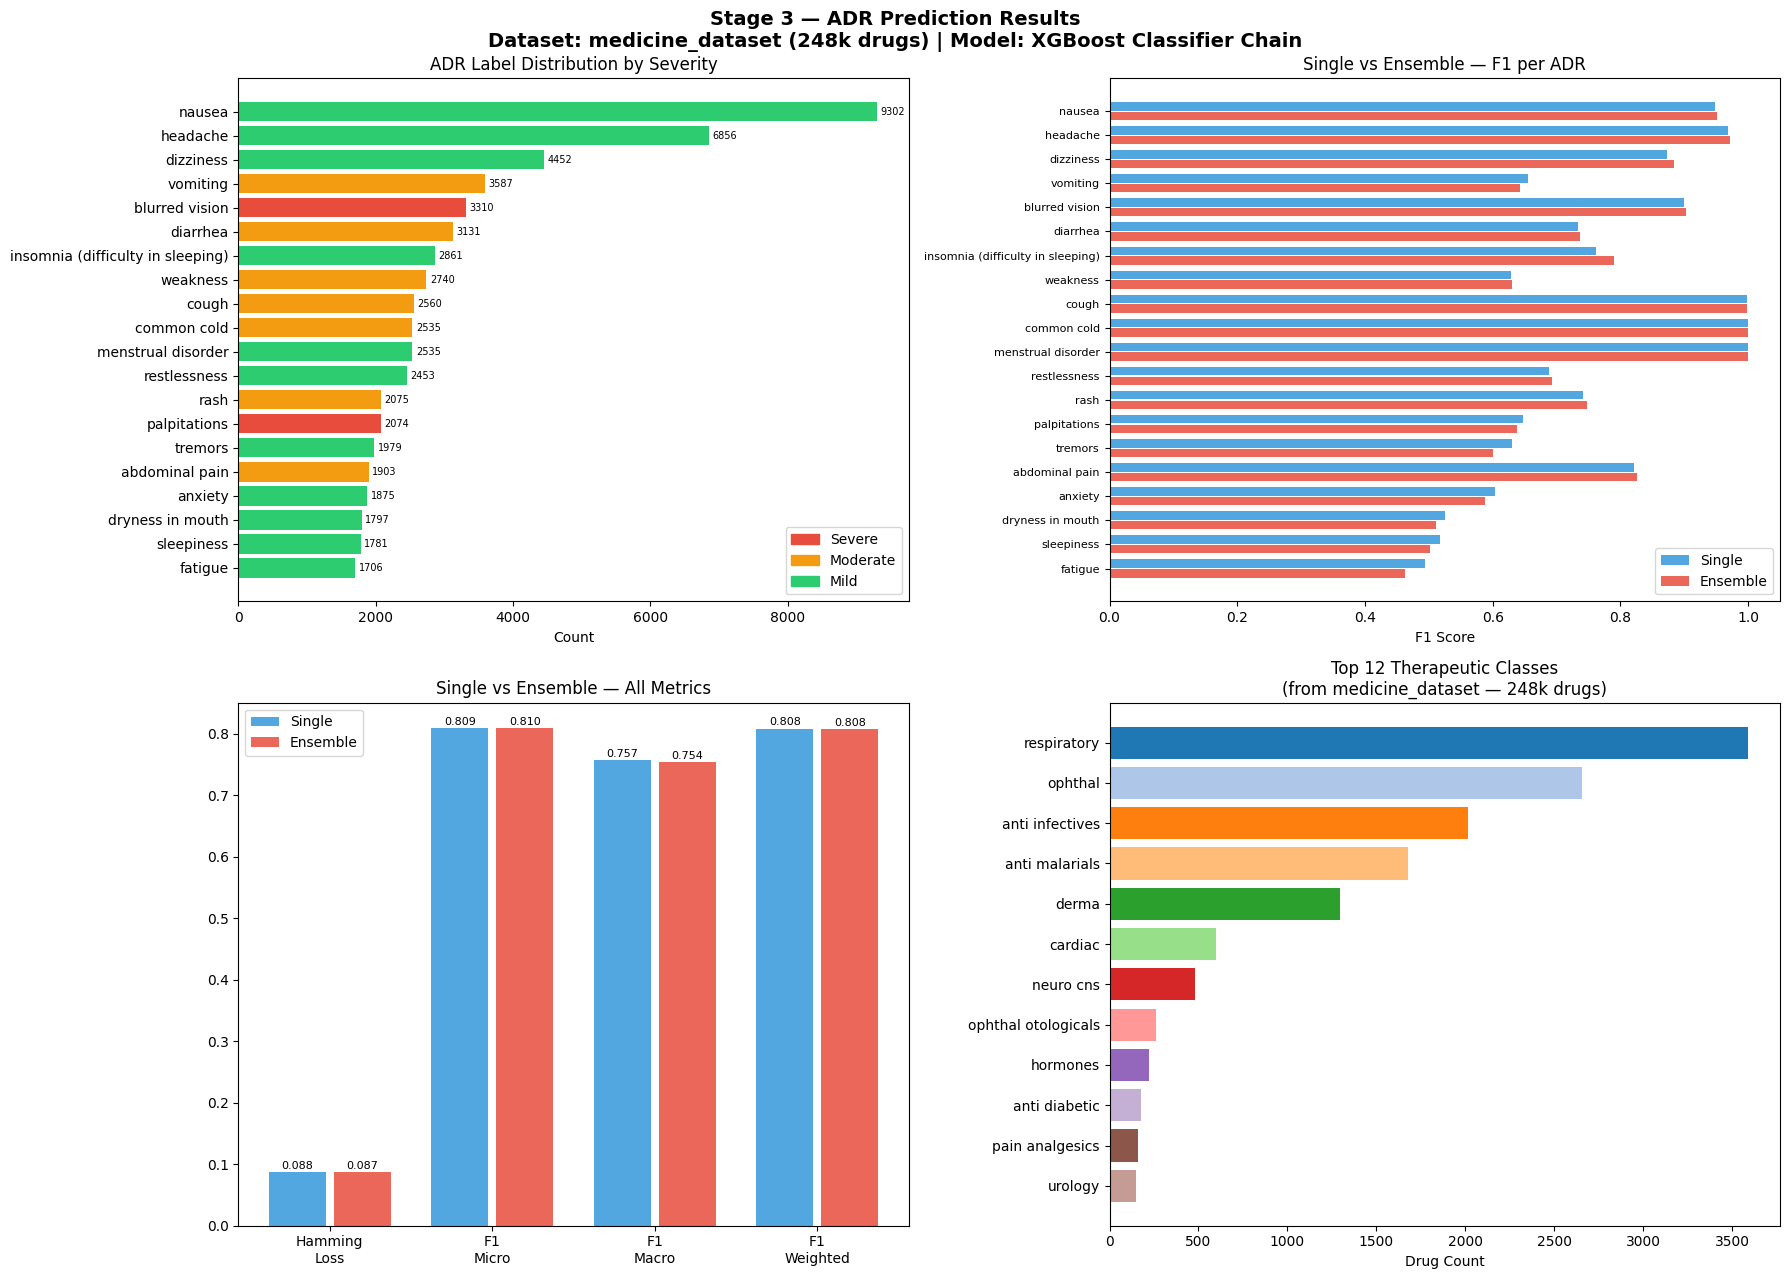

Plots saved ✅


In [19]:
SEVERITY_LABELS = {0:'SEVERE', 1:'MODERATE', 2:'MILD'}
SEVERITY_ADVICE = {
    'SEVERE'  : '🔴 STOP. Seek IMMEDIATE medical help.',
    'MODERATE': '🟡 Monitor. Consult doctor promptly.',
    'MILD'    : '🟢 Usually resolves. Inform at next visit.'
}

def sev_color(adr):
    s = ADR_SEVERITY.get(adr, 2)
    return '#e74c3c' if s==0 else '#f39c12' if s==1 else '#2ecc71'

colors = [sev_color(a) for a in TOP_ADRS]

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle(
    'Stage 3 — ADR Prediction Results\n'
    'Dataset: medicine_dataset (248k drugs) | '
    'Model: XGBoost Classifier Chain',
    fontsize=14, fontweight='bold')

# Plot 1 — ADR label distribution
ax1 = axes[0, 0]
counts = y.sum(axis=0)
ax1.barh(TOP_ADRS, counts, color=colors)
ax1.set_xlabel('Count')
ax1.set_title('ADR Label Distribution by Severity')
ax1.invert_yaxis()
ax1.legend(handles=[
    mpatches.Patch(color='#e74c3c', label='Severe'),
    mpatches.Patch(color='#f39c12', label='Moderate'),
    mpatches.Patch(color='#2ecc71', label='Mild')
], loc='lower right')
for i, cnt in enumerate(counts):
    ax1.text(cnt+50, i, str(int(cnt)),
             va='center', fontsize=7)

# Plot 2 — Single vs Ensemble F1
ax2 = axes[0, 1]
pos = np.arange(len(TOP_ADRS))
ax2.barh(pos-0.2, f1_s_per, 0.35,
         label='Single',   color='#3498db', alpha=0.85)
ax2.barh(pos+0.2, f1_e_per, 0.35,
         label='Ensemble', color='#e74c3c', alpha=0.85)
ax2.set_yticks(pos)
ax2.set_yticklabels(TOP_ADRS, fontsize=8)
ax2.set_xlabel('F1 Score')
ax2.set_title('Single vs Ensemble — F1 per ADR')
ax2.set_xlim(0, 1.05)
ax2.legend()
ax2.invert_yaxis()

# Plot 3 — Metrics comparison
ax3 = axes[1, 0]
metrics = ['Hamming\nLoss','F1\nMicro',
           'F1\nMacro','F1\nWeighted']
sv = [hl_s, f1_mi_s, f1_ma_s, f1_wt_s]
ev = [hl_e, f1_mi_e, f1_ma_e, f1_wt_e]
x  = np.arange(len(metrics))
b1 = ax3.bar(x-0.2, sv, 0.35,
             label='Single',   color='#3498db', alpha=0.85)
b2 = ax3.bar(x+0.2, ev, 0.35,
             label='Ensemble', color='#e74c3c', alpha=0.85)
ax3.set_xticks(x)
ax3.set_xticklabels(metrics)
ax3.set_title('Single vs Ensemble — All Metrics')
ax3.legend()
for bar in list(b1)+list(b2):
    ax3.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.005,
        f'{bar.get_height():.3f}',
        ha='center', fontsize=8)

# Plot 4 — Therapeutic class distribution
ax4 = axes[1, 1]
tc_counts = (stage3_df['therapeutic_class']
             .value_counts().head(12))
ax4.barh(tc_counts.index, tc_counts.values,
         color=plt.cm.tab20.colors[:len(tc_counts)])
ax4.set_xlabel('Drug Count')
ax4.set_title('Top 12 Therapeutic Classes\n'
              '(from medicine_dataset — 248k drugs)')
ax4.invert_yaxis()

plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/stage3_results.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved ✅")

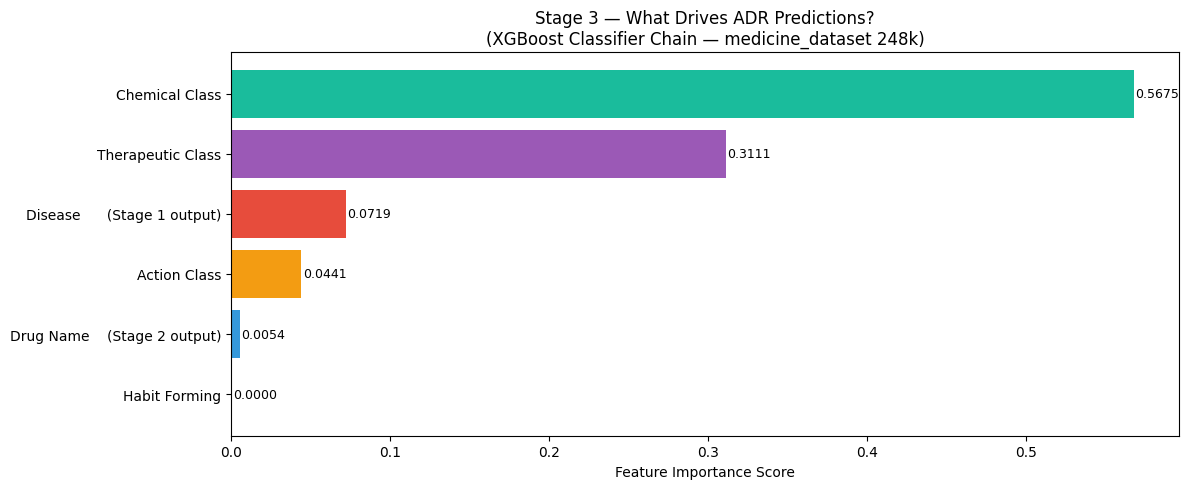

Feature importance saved ✅


In [20]:
# Feature importance from first estimator in chain
importances = chain_model.estimators_[0].feature_importances_

feat_labels = [
    'Disease      (Stage 1 output)',
    'Drug Name    (Stage 2 output)',
    'Therapeutic Class',
    'Chemical Class',
    'Habit Forming',
    'Action Class',
]

sorted_idx = np.argsort(importances)
bar_colors = ['#e74c3c','#3498db','#9b59b6',
              '#1abc9c','#e67e22','#f39c12','#2ecc71']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(
    [feat_labels[i] for i in sorted_idx],
    importances[sorted_idx],
    color=[bar_colors[i % len(bar_colors)] 
           for i in sorted_idx]
)
ax.set_xlabel('Feature Importance Score')
ax.set_title(
    'Stage 3 — What Drives ADR Predictions?\n'
    '(XGBoost Classifier Chain — medicine_dataset 248k)')
for bar in bars:
    ax.text(
        bar.get_width()+0.001,
        bar.get_y()+bar.get_height()/2,
        f'{bar.get_width():.4f}',
        va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/stage3_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance saved ✅")

In [21]:
save_dir = '../models_trained'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(chain_model,     f'{save_dir}/chain_adr_model.pkl')
joblib.dump(ensemble_models, f'{save_dir}/ensemble_adr_models.pkl')
joblib.dump(mlb,             f'{save_dir}/mlb_adr.pkl')
joblib.dump(le_drug_s3,      f'{save_dir}/le_adr_drug.pkl')
joblib.dump(le_tc,           f'{save_dir}/le_adr_tc.pkl')
joblib.dump(le_cc,           f'{save_dir}/le_adr_cc.pkl')
joblib.dump(le_ac,           f'{save_dir}/le_adr_ac.pkl')
joblib.dump(TOP_ADRS,        f'{save_dir}/stage3_adr_labels.pkl')
joblib.dump(FEATURE_COLS,    f'{save_dir}/stage3_feature_cols.pkl')
joblib.dump(ADR_SEVERITY,    f'{save_dir}/adr_severity_dict.pkl')
joblib.dump(chain_order,     f'{save_dir}/chain_order.pkl')
joblib.dump(hf_map,          f'{save_dir}/hf_map.pkl')
joblib.dump(med_mapping,     f'{save_dir}/disease_mapping.pkl')

print("All Stage 3 models saved ✅")
print()
print("models_trained/ contents:")
for f in sorted(os.listdir(save_dir)):
    sz = os.path.getsize(f'{save_dir}/{f}') / 1024
    print(f"  {f:<45} {sz:>8.1f} KB")

All Stage 3 models saved ✅

models_trained/ contents:
  X_test.csv                                       256.6 KB
  X_train_clean.npy                               4059.1 KB
  adr_severity_dict.pkl                              0.3 KB
  chain_adr_model.pkl                             8318.8 KB
  chain_order.pkl                                    0.1 KB
  disease_mapping.pkl                                0.5 KB
  drug_class_bridge.pkl                              4.1 KB
  drug_feature_names.pkl                             2.3 KB
  drug_scaler.pkl                                    3.7 KB
  ensemble_adr_models.pkl                       128840.6 KB
  feature_names.pkl                                  2.3 KB
  hf_map.pkl                                         0.1 KB
  label_encoder.pkl                                  1.1 KB
  le_adr_ac.pkl                                      2.0 KB
  le_adr_cc.pkl                                      1.9 KB
  le_adr_drug.pkl                             

In [22]:
# Load all Stage 1 + 2 models
xgb_disease   = joblib.load('../models_trained/xgb_disease_model.pkl')
le_s1         = joblib.load('../models_trained/label_encoder.pkl')
severity_dict = joblib.load('../models_trained/severity_dict.pkl')
feature_names = joblib.load('../models_trained/feature_names.pkl')
rf_drug       = joblib.load('../models_trained/rf_drug_model.pkl')
le_drug_s2    = joblib.load('../models_trained/le_drug.pkl')
print("Stage 1 + 2 models loaded ✅")
TC_BRIDGE = {
    'antipyretics':'pain analgesics',
    'antibiotics':'anti infectives',
    'antiviral drugs':'anti infectives',
    'antimalarial drugs':'anti malarial',
    'antiretroviral drugs':'anti infectives',
    'antihistamines':'respiratory',
    'bronchodilators':'respiratory',
    'corticosteroids':'hormones',
    'levothyroxine':'hormones',
    'methimazole':'hormones',
    'dextrose':'anti diabetic',
    'aspirin':'pain analgesics',
    'ibuprofen':'pain analgesics',
    'lisinopril':'cardiac',
    'omeprazole':'gastro intestinal',
    'sumatriptan':'neuro cns',
    'nitrofurantoin':'anti infectives',
    'acyclovir':'anti infectives',
    'isoniazid':'anti infectives',
    'chloroquine':'anti malarial',
    'sofosbuvir':'anti infectives',
    'entecavir':'anti infectives',
    'fluconazole':'anti infectives',
    'acetaminophen':'pain analgesics',
    'ciprofloxacin':'anti infectives',
    'prednisolone':'hormones',
    'ursodiol':'gastro intestinal',
    'diphenhydramine':'respiratory',
    'levocetirizine':'respiratory',
    'dulaglutide':'anti diabetic',
    'clindamycin':'anti infectives',
    'meclizine':'neuro cns',
    'hydrocortisone':'derma',
    'diosmin':'cardiac',
    'mupirocin':'derma',
    'isotretinoin':'derma',
    'hydroxychloroquine':'musculo skeletal',
    'cholestyramine':'gastro intestinal',
    'amoxicillin':'anti infectives',
    'montelukast':'respiratory',
    'biktarvy':'anti infectives',
    'dupilumab':'derma',
    'entereg':'gastro intestinal',
    'ranolazine':'cardiac',
    'clopidogrel':'cardiac',
    'ustekinumab':'derma',
    'sodium hyaluronate':'musculo skeletal',
    'insulin glargine':'anti diabetic',
    'peginterferon alfa':'anti infectives',
    'ribavirin':'anti infectives',
    'supportive_care':'gastro intestinal',
}

def full_pipeline_predict(symptom_list, verbose=True):
    result = {}

    # STAGE 1 — Symptoms → Disease
    vec = np.zeros(len(feature_names))
    for sym in symptom_list:
        s = sym.strip().lower().replace(' ','_')
        if s in feature_names:
            vec[feature_names.index(s)] = \
                severity_dict.get(s, 1)
    disease_code = xgb_disease.predict([vec])[0]
    disease_name = le_s1.inverse_transform(
        [disease_code])[0]
    disease_conf = xgb_disease.predict_proba(
        [vec]).max()
    result['disease'] = disease_name

    # STAGE 2 — Symptoms → Drug
    drug_code = rf_drug.predict([vec])[0]
    drug_name = le_drug_s2.inverse_transform(
        [drug_code])[0]
    drug_conf = rf_drug.predict_proba([vec]).max()
    result['drug'] = drug_name

    # STAGE 3 — Disease + Drug → ADRs
    try:    d_enc = le_disease_s1.transform(
                [disease_name.strip()])[0]
    except: d_enc = 0

    drug_lower = drug_name.lower().strip()
    try:
        dr_enc = le_drug_s3.transform([drug_lower])[0]
    except:
        disease_drugs = stage3_df[
            stage3_df['disease'] == disease_name]['drug_enc']
        dr_enc = int(disease_drugs.mode()[0]) if len(disease_drugs) > 0 else 0

    # Look up drug features
    drug_row = new_df[
        new_df['drug_lower'] == drug_lower]
    if len(drug_row) > 0:
        tc_val = str(drug_row.iloc[0][
            'therapeutic_class']).lower().strip()
        tc_val = TC_BRIDGE.get(tc_val, tc_val) 
        cc_val = str(drug_row.iloc[0][
            'chemical_class']).lower().strip()
        hf_val = str(drug_row.iloc[0][
            'habit_forming']).strip()
        ac_val = str(drug_row.iloc[0].get(
            'action_class', drug_row.iloc[0].get(
            'Action Class', 'unknown'))).lower().strip()
        
    else:
        tc_val  = TC_BRIDGE.get(drug_lower, 'unknown')
        cc_val  = 'unknown'
        hf_val  = 'No'
        ac_val  = 'unknown'
        

    try:    tc_enc = le_tc.transform([tc_val])[0]
    except: tc_enc = 0
    try:    cc_enc = le_cc.transform([cc_val])[0]
    except: cc_enc = 0
    try:    ac_enc = le_ac.transform([ac_val])[0]
    except: ac_enc = 0
    hf_enc = hf_map.get(hf_val, 1)

    x3 = np.array([[d_enc, dr_enc, tc_enc,
                    cc_enc, hf_enc, ac_enc]])

    proba = chain_model.predict_proba(x3)[0]
    adr_results = sorted(
        zip(TOP_ADRS, proba),
        key=lambda x: x[1], reverse=True)
    result['adrs'] = adr_results

    if verbose:
        print("="*72)
        print("  FULL 3-STAGE PIPELINE PREDICTION REPORT")
        print("="*72)
        print(f"  Symptoms : {symptom_list}")
        print()
        print(f"  STAGE 1 → Disease : {disease_name}"
              f" ({disease_conf*100:.1f}%)")
        print(f"  STAGE 2 → Drug    : {drug_name}"
              f" ({drug_conf*100:.1f}%)")
        print(f"            TC      : {tc_val}")
        print(f"            CC      : {cc_val}")
        print(f"            Habit   : {hf_val}")
        print()
        print(f"  STAGE 3 → Predicted ADRs:")
        print(f"  {'ADR':<45} {'Prob':>8}  "
              f"Severity    Action")
        print("  " + "-"*80)
        for adr, prob in adr_results:
            if prob > 0.05:
                sev    = SEVERITY_LABELS[
                    ADR_SEVERITY.get(adr, 2)]
                advice = SEVERITY_ADVICE[sev]
                print(f"  {adr:<45} {prob:>7.1%}"
                      f"  {sev:<10}  {advice}")
        print("="*72)

    return result

# Test cases — using exact Training.csv symptom names
print("TEST 1 — Malaria:")
r1 = full_pipeline_predict([
    'chills','vomiting','high_fever',
    'sweating','headache','nausea',
    'diarrhoea','muscle_pain'])

print("\nTEST 2 — Hypothyroidism:")
r2 = full_pipeline_predict([
    'fatigue','weight_gain',
    'cold_hands_and_feets','constipation',
    'depression','enlarged_thyroid',
    'brittle_nails','swollen_extremities'])

print("\nTEST 3 — Diabetes:")
r3 = full_pipeline_predict([
    'increased_appetite','polyuria',
    'excessive_hunger','fatigue',
    'weight_loss','blurred_and_distorted_vision',
    'restlessness','irregular_sugar_level'])

Stage 1 + 2 models loaded ✅
TEST 1 — Malaria:
  FULL 3-STAGE PIPELINE PREDICTION REPORT
  Symptoms : ['chills', 'vomiting', 'high_fever', 'sweating', 'headache', 'nausea', 'diarrhoea', 'muscle_pain']

  STAGE 1 → Disease : Malaria (99.7%)
  STAGE 2 → Drug    : chloroquine (42.2%)
            TC      : anti malarial
            CC      : unknown
            Habit   : No

  STAGE 3 → Predicted ADRs:
  ADR                                               Prob  Severity    Action
  --------------------------------------------------------------------------------
  headache                                        98.3%  MILD        🟢 Usually resolves. Inform at next visit.
  dizziness                                       97.6%  MILD        🟢 Usually resolves. Inform at next visit.
  weakness                                        74.1%  MODERATE    🟡 Monitor. Consult doctor promptly.
  vomiting                                        18.6%  MODERATE    🟡 Monitor. Consult doctor promptly.

TEST 2

In [23]:
# Test cases — using exact Training.csv symptom names
print("TEST 1 — Malaria:")
r1 = full_pipeline_predict([
    'chills','vomiting','high_fever',
    'sweating','headache','nausea',
    'diarrhoea','muscle_pain'])

print("\nTEST 2 — Hypothyroidism:")
r2 = full_pipeline_predict([
    'fatigue','weight_gain',
    'cold_hands_and_feets','constipation',
    'depression','enlarged_thyroid',
    'brittle_nails','swollen_extremities'])

print("\nTEST 3 — Diabetes:")
r3 = full_pipeline_predict([
    'increased_appetite','polyuria',
    'excessive_hunger','fatigue',
    'weight_loss','blurred_and_distorted_vision',
    'restlessness','irregular_sugar_level'])

TEST 1 — Malaria:
  FULL 3-STAGE PIPELINE PREDICTION REPORT
  Symptoms : ['chills', 'vomiting', 'high_fever', 'sweating', 'headache', 'nausea', 'diarrhoea', 'muscle_pain']

  STAGE 1 → Disease : Malaria (99.7%)
  STAGE 2 → Drug    : chloroquine (42.2%)
            TC      : anti malarial
            CC      : unknown
            Habit   : No

  STAGE 3 → Predicted ADRs:
  ADR                                               Prob  Severity    Action
  --------------------------------------------------------------------------------
  headache                                        98.3%  MILD        🟢 Usually resolves. Inform at next visit.
  dizziness                                       97.6%  MILD        🟢 Usually resolves. Inform at next visit.
  weakness                                        74.1%  MODERATE    🟡 Monitor. Consult doctor promptly.
  vomiting                                        18.6%  MODERATE    🟡 Monitor. Consult doctor promptly.

TEST 2 — Hypothyroidism:
  FULL 3-

In [24]:
# Test with more diseases
print("TEST — Dengue:")
full_pipeline_predict([
    'skin_rash', 'chills', 'joint_pain',
    'vomiting', 'fatigue', 'high_fever',
    'headache', 'nausea', 'loss_of_appetite',
    'pain_behind_the_eyes', 'back_pain',
    'muscle_pain', 'red_spots_over_body'
])

print("\nTEST — Tuberculosis:")
full_pipeline_predict([
    'chills', 'vomiting', 'fatigue',
    'weight_loss', 'cough', 'high_fever',
    'breathlessness', 'sweating',
    'loss_of_appetite', 'mild_fever',
    'yellowing_of_eyes', 'swelled_lymph_nodes',
    'malaise', 'phlegm', 'chest_pain',
    'blood_in_sputum'
])

print("\nTEST — Jaundice:")
full_pipeline_predict([
    'itching', 'vomiting', 'fatigue',
    'weight_loss', 'high_fever',
    'yellowish_skin', 'dark_urine',
    'abdominal_pain'
])

print("\nTEST — Pneumonia:")
full_pipeline_predict([
    'chills', 'fatigue', 'cough',
    'high_fever', 'breathlessness',
    'sweating', 'malaise',
    'phlegm', 'chest_pain', 'fast_heart_rate',
    'rusty_sputum'
])

print("\nTEST — Typhoid:")
full_pipeline_predict([
    'chills', 'vomiting', 'fatigue',
    'high_fever', 'headache', 'nausea',
    'constipation', 'abdominal_pain',
    'diarrhoea', 'toxic_look_(typhos)',
    'belly_pain'
])

TEST — Dengue:
  FULL 3-STAGE PIPELINE PREDICTION REPORT
  Symptoms : ['skin_rash', 'chills', 'joint_pain', 'vomiting', 'fatigue', 'high_fever', 'headache', 'nausea', 'loss_of_appetite', 'pain_behind_the_eyes', 'back_pain', 'muscle_pain', 'red_spots_over_body']

  STAGE 1 → Disease : Dengue (99.5%)
  STAGE 2 → Drug    : acetaminophen (72.0%)
            TC      : pain analgesics
            CC      : unknown
            Habit   : No

  STAGE 3 → Predicted ADRs:
  ADR                                               Prob  Severity    Action
  --------------------------------------------------------------------------------
  sleepiness                                      94.5%  MILD        🟢 Usually resolves. Inform at next visit.
  vomiting                                        27.0%  MODERATE    🟡 Monitor. Consult doctor promptly.
  dryness in mouth                                 8.4%  MILD        🟢 Usually resolves. Inform at next visit.
  blurred vision                               

{'disease': 'Typhoid',
 'drug': 'ciprofloxacin',
 'adrs': [('nausea', np.float64(0.9996687173843384)),
  ('rash', np.float64(0.992863118648529)),
  ('vomiting', np.float64(0.8178170323371887)),
  ('diarrhea', np.float64(0.010237990878522396)),
  ('headache', np.float64(0.0038150849286466837)),
  ('weakness', np.float64(0.0017005233094096184)),
  ('insomnia (difficulty in sleeping)', np.float64(0.0016518458724021912)),
  ('cough', np.float64(0.0016250305343419313)),
  ('restlessness', np.float64(0.0007111710729077458)),
  ('abdominal pain', np.float64(0.0007020776974968612)),
  ('sleepiness', np.float64(0.000620833714492619)),
  ('blurred vision', np.float64(0.000586531707085669)),
  ('dizziness', np.float64(0.0005764603265561163)),
  ('dryness in mouth', np.float64(0.00047841350897215307)),
  ('anxiety', np.float64(0.00035469274735078216)),
  ('fatigue', np.float64(0.00028633110923692584)),
  ('menstrual disorder', np.float64(0.000267709867330268)),
  ('palpitations', np.float64(0.0002